# Spatial operations

In this notebook we will do spatial operations using DuckDB and Python.

<a target="_blank" href="https://colab.research.google.com/github/kraina-ai/srai-tutorial/blob/dawts2026/02_spatial_operations.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
## Uncomment the line below when running on Google Colab
# %pip install geopandas pooch folium branca mapclassify h3 shapely

## Transactions data analysis - RCN dataset for Warsaw

We will use public data from deweloperuch github repository and aggregate it into a heatmap using H3 cells.

In [1]:
from pooch import retrieve, Unzip

In [2]:
RCN_WARSAW_URL = 'https://github.com/deweloperuch/rejestr-cen-nieruchomosci/raw/refs/heads/main/data/warszawa/warszawa_rcn.zip'

rcn_file_path = retrieve(RCN_WARSAW_URL, path='files/rcn', known_hash=None, processor=Unzip())[0]

In [3]:
import geopandas as gpd

gpd.list_layers(rcn_file_path)

,name,geometry_type
0,RCN_Transakcja,NaN
1,RCN_Nieruchomosc,NaN
2,RCN_Dzialka,Polygon
3,RCN_Budynek,Unknown
4,RCN_Lokal,Point
5,RCN_Adres,NaN
6,RCN_Dokument,NaN


In [ ]:
flats = gpd.read_file(rcn_file_path, layer="RCN_Lokal").rename(
    columns={"powUzytkowaLokalu": "area_m2", "cenaLokaluBrutto": "price"}
)
flats

,gml_id,idLokalu,funkcjaLokalu,liczbaIzb,nrKondygnacji,area_m2,powUzytkowaLokalu_uom,price,kwotaPodatkuVAT,powUzytkowaPomieszczenPrzynal,powUzytkowaPomieszczenPrzynal_uom,geometry
0,PL.PZGiK.5346.RCN_07bacc2a-10c1-4335-acf6-c981...,146517_8.0702.92_BUD.74_LOK,1,2,3.0,35.32,m2,410257.86,30398.58,NaN,NaN,POINT (7495419.11 5784357.36)
1,PL.PZGiK.5346.RCN_f7c626dd-bf6e-40b7-875e-6a3b...,146517_8.0702.92_BUD.55_LOK,1,3,7.0,57.05,m2,703010.04,52074.82,NaN,NaN,POINT (7495419.11 5784357.36)
2,PL.PZGiK.5346.RCN_8a9617fa-ca5e-4a8c-aa4c-5d7b...,146517_8.0702.92_BUD.113_LOK,1,3,5.0,58.16,m2,691373.99,51212.89,NaN,NaN,POINT (7495419.11 5784357.36)
3,PL.PZGiK.5346.RCN_0d459d46-1723-4202-86b4-0943...,146517_8.0702.92_BUD.117_LOK,1,2,6.0,42.92,m2,550847.30,40803.50,NaN,NaN,POINT (7495419.11 5784357.36)
4,PL.PZGiK.5346.RCN_06ad0963-7617-4a8b-899a-754e...,146517_8.0702.92_BUD.87_LOK,1,1,6.0,26.48,m2,323841.49,23988.26,NaN,NaN,POINT (7495419.11 5784357.36)
...,...,...,...,...,...,...,...,...,...,...,...,...
13196,PL.PZGiK.5346.RCN_fd89c4a5-a59e-4847-9cfd-8ac9...,146503_8.1636.249_BUD.25_LOK,1,2,4.0,40.43,m2,525528.13,NaN,NaN,NaN,POINT (7504451.71 5798377.6)
13197,PL.PZGiK.5346.RCN_2a00043d-5036-4415-b8c9-3cfc...,146503_8.1636.249_BUD.66_LOK,1,3,4.0,55.50,m2,704403.60,NaN,NaN,NaN,POINT (7504451.71 5798377.6)
13198,PL.PZGiK.5346.RCN_f2f331de-0ecd-4017-86eb-1c14...,146503_8.1631.301_BUD.23_LOK,1,4,4.0,77.09,m2,675668.00,50049.48,NaN,NaN,POINT (7503253.23 5798482.39)
13199,PL.PZGiK.5346.RCN_0d748072-417b-4d26-a491-d31a...,146503_8.1631.302_BUD.113_LOK,1,3,4.0,57.76,m2,617202.00,45718.67,NaN,NaN,POINT (7503360.43 5798492.72)


<Axes: >

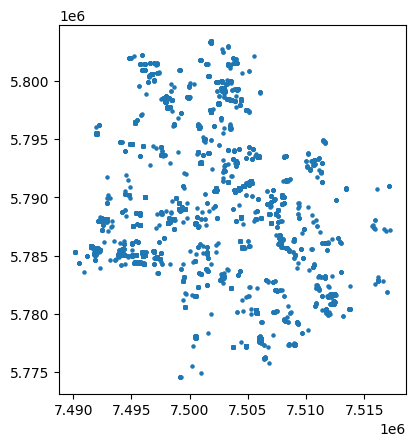

In [83]:
flats.plot(markersize=5)

In [ ]:
flats["price_per_m2"] = (flats["price"] / flats["area_m2"]).round(2)
flats

,gml_id,idLokalu,funkcjaLokalu,liczbaIzb,nrKondygnacji,area_m2,powUzytkowaLokalu_uom,price,kwotaPodatkuVAT,powUzytkowaPomieszczenPrzynal,powUzytkowaPomieszczenPrzynal_uom,geometry,price_per_m2
0,PL.PZGiK.5346.RCN_07bacc2a-10c1-4335-acf6-c981...,146517_8.0702.92_BUD.74_LOK,1,2,3.0,35.32,m2,410257.86,30398.58,NaN,NaN,POINT (7495419.11 5784357.36),11615.45
1,PL.PZGiK.5346.RCN_f7c626dd-bf6e-40b7-875e-6a3b...,146517_8.0702.92_BUD.55_LOK,1,3,7.0,57.05,m2,703010.04,52074.82,NaN,NaN,POINT (7495419.11 5784357.36),12322.70
2,PL.PZGiK.5346.RCN_8a9617fa-ca5e-4a8c-aa4c-5d7b...,146517_8.0702.92_BUD.113_LOK,1,3,5.0,58.16,m2,691373.99,51212.89,NaN,NaN,POINT (7495419.11 5784357.36),11887.45
3,PL.PZGiK.5346.RCN_0d459d46-1723-4202-86b4-0943...,146517_8.0702.92_BUD.117_LOK,1,2,6.0,42.92,m2,550847.30,40803.50,NaN,NaN,POINT (7495419.11 5784357.36),12834.28
4,PL.PZGiK.5346.RCN_06ad0963-7617-4a8b-899a-754e...,146517_8.0702.92_BUD.87_LOK,1,1,6.0,26.48,m2,323841.49,23988.26,NaN,NaN,POINT (7495419.11 5784357.36),12229.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13196,PL.PZGiK.5346.RCN_fd89c4a5-a59e-4847-9cfd-8ac9...,146503_8.1636.249_BUD.25_LOK,1,2,4.0,40.43,m2,525528.13,NaN,NaN,NaN,POINT (7504451.71 5798377.6),12998.47
13197,PL.PZGiK.5346.RCN_2a00043d-5036-4415-b8c9-3cfc...,146503_8.1636.249_BUD.66_LOK,1,3,4.0,55.50,m2,704403.60,NaN,NaN,NaN,POINT (7504451.71 5798377.6),12691.96
13198,PL.PZGiK.5346.RCN_f2f331de-0ecd-4017-86eb-1c14...,146503_8.1631.301_BUD.23_LOK,1,4,4.0,77.09,m2,675668.00,50049.48,NaN,NaN,POINT (7503253.23 5798482.39),8764.66
13199,PL.PZGiK.5346.RCN_0d748072-417b-4d26-a491-d31a...,146503_8.1631.302_BUD.113_LOK,1,3,4.0,57.76,m2,617202.00,45718.67,NaN,NaN,POINT (7503360.43 5798492.72),10685.63


In [24]:
flats["price_per_m2"].describe(
    [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)

count    13198.00
mean     14618.22
std       4843.31
min          7.32
1%        6634.78
5%        8852.57
10%       9720.39
25%      11599.27
50%      14000.00
75%      16394.89
90%      20020.59
95%      23016.60
99%      30481.80
max      68993.45
Name: price_per_m2, dtype: float64

<Axes: >

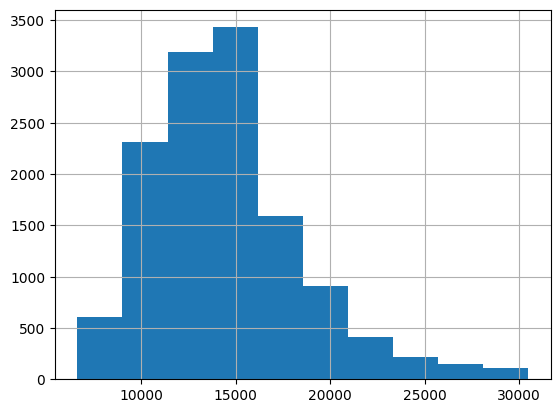

In [25]:
flats_filtered = flats[
    flats["price_per_m2"].between(
        flats["price_per_m2"].quantile(0.01), flats["price_per_m2"].quantile(0.99)
    )
]
flats_filtered["price_per_m2"].hist()

<Axes: >

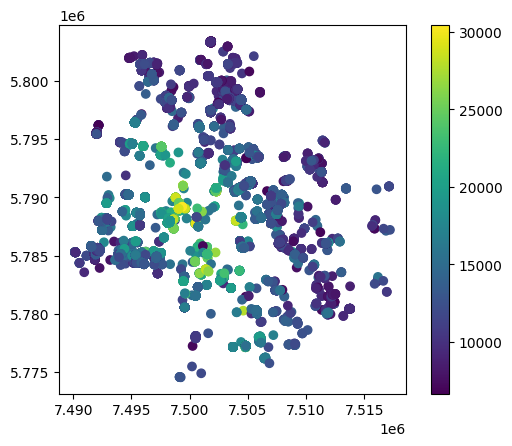

In [26]:
flats_filtered.plot("price_per_m2", legend=True)

In [43]:
import h3


def point_to_h3(point):
    lon = point.x
    lat = point.y
    return h3.latlng_to_cell(lat, lon, 8)


flats_filtered["h3"] = flats_filtered.geometry.to_crs(4326).apply(point_to_h3)
flats_filtered

,gml_id,idLokalu,funkcjaLokalu,liczbaIzb,nrKondygnacji,area_m2,powUzytkowaLokalu_uom,price,kwotaPodatkuVAT,powUzytkowaPomieszczenPrzynal,powUzytkowaPomieszczenPrzynal_uom,geometry,price_per_m2,h3
0,PL.PZGiK.5346.RCN_07bacc2a-10c1-4335-acf6-c981...,146517_8.0702.92_BUD.74_LOK,1,2,3.0,35.32,m2,410257.86,30398.58,NaN,NaN,POINT (7495419.11 5784357.36),11615.45,881f52263bfffff
1,PL.PZGiK.5346.RCN_f7c626dd-bf6e-40b7-875e-6a3b...,146517_8.0702.92_BUD.55_LOK,1,3,7.0,57.05,m2,703010.04,52074.82,NaN,NaN,POINT (7495419.11 5784357.36),12322.70,881f52263bfffff
2,PL.PZGiK.5346.RCN_8a9617fa-ca5e-4a8c-aa4c-5d7b...,146517_8.0702.92_BUD.113_LOK,1,3,5.0,58.16,m2,691373.99,51212.89,NaN,NaN,POINT (7495419.11 5784357.36),11887.45,881f52263bfffff
3,PL.PZGiK.5346.RCN_0d459d46-1723-4202-86b4-0943...,146517_8.0702.92_BUD.117_LOK,1,2,6.0,42.92,m2,550847.30,40803.50,NaN,NaN,POINT (7495419.11 5784357.36),12834.28,881f52263bfffff
4,PL.PZGiK.5346.RCN_06ad0963-7617-4a8b-899a-754e...,146517_8.0702.92_BUD.87_LOK,1,1,6.0,26.48,m2,323841.49,23988.26,NaN,NaN,POINT (7495419.11 5784357.36),12229.66,881f52263bfffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13196,PL.PZGiK.5346.RCN_fd89c4a5-a59e-4847-9cfd-8ac9...,146503_8.1636.249_BUD.25_LOK,1,2,4.0,40.43,m2,525528.13,NaN,NaN,NaN,POINT (7504451.71 5798377.6),12998.47,881f53ca15fffff
13197,PL.PZGiK.5346.RCN_2a00043d-5036-4415-b8c9-3cfc...,146503_8.1636.249_BUD.66_LOK,1,3,4.0,55.50,m2,704403.60,NaN,NaN,NaN,POINT (7504451.71 5798377.6),12691.96,881f53ca15fffff
13198,PL.PZGiK.5346.RCN_f2f331de-0ecd-4017-86eb-1c14...,146503_8.1631.301_BUD.23_LOK,1,4,4.0,77.09,m2,675668.00,50049.48,NaN,NaN,POINT (7503253.23 5798482.39),8764.66,881f53ca07fffff
13199,PL.PZGiK.5346.RCN_0d748072-417b-4d26-a491-d31a...,146503_8.1631.302_BUD.113_LOK,1,3,4.0,57.76,m2,617202.00,45718.67,NaN,NaN,POINT (7503360.43 5798492.72),10685.63,881f53ca39fffff


In [ ]:
aggregated_flats = (
    flats_filtered.groupby("h3")
    .agg(
        price_per_m2=("price_per_m2", "median"),
        total_transactions=("gml_id", "nunique"),
    )
    .round(2)
    .reset_index()
)
aggregated_flats

,h3,price_per_m2,total_transactions
0,881f522481fffff,10964.91,32
1,881f522485fffff,7166.53,1
2,881f52248bfffff,12621.23,1
3,881f52248dfffff,11086.74,2
4,881f522493fffff,17726.25,1
...,...,...,...
306,881f53d9b3fffff,8645.42,2
307,881f53d9b7fffff,12197.93,51
308,881f53d9bbfffff,9010.24,2
309,881f53d9c7fffff,8317.66,5


In [76]:
from shapely import Polygon


def h3_to_geometry(h3_id):
    coords = h3.cell_to_boundary(h3_id)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)


aggregated_flats = gpd.GeoDataFrame(
    aggregated_flats, geometry=aggregated_flats["h3"].apply(h3_to_geometry), crs=4326
)
aggregated_flats

,h3,price_per_m2,total_transactions,geometry
0,881f522481fffff,10964.91,32,"POLYGON ((21.00884 52.13882, 21.00612 52.13467..."
1,881f522485fffff,7166.53,1,"POLYGON ((20.99841 52.13387, 20.9957 52.12973,..."
2,881f52248bfffff,12621.23,1,"POLYGON ((21.01927 52.14376, 21.01655 52.13962..."
3,881f52248dfffff,11086.74,2,"POLYGON ((20.99612 52.14136, 20.99341 52.13721..."
4,881f522493fffff,17726.25,1,"POLYGON ((21.05742 52.13613, 21.05471 52.13199..."
...,...,...,...,...
306,881f53d9b3fffff,8645.42,2,"POLYGON ((20.97468 52.32799, 20.97196 52.32386..."
307,881f53d9b7fffff,12197.93,51,"POLYGON ((20.96422 52.32306, 20.9615 52.31893,..."
308,881f53d9bbfffff,9010.24,2,"POLYGON ((20.97238 52.33545, 20.96966 52.33132..."
309,881f53d9c7fffff,8317.66,5,"POLYGON ((20.9295 52.35793, 20.92678 52.3538, ..."


In [ ]:
aggregated_flats.explore(
    "price_per_m2",
    cmap="RdYlGn_r",
    tiles="CartoDB Voyager",
    style_kwds=dict(color="black", weight=0.5),
)